In [6]:
%cd /mnt/sda/xxy/Project/ClustView


/mnt/sda/xxy/Project/ClustView


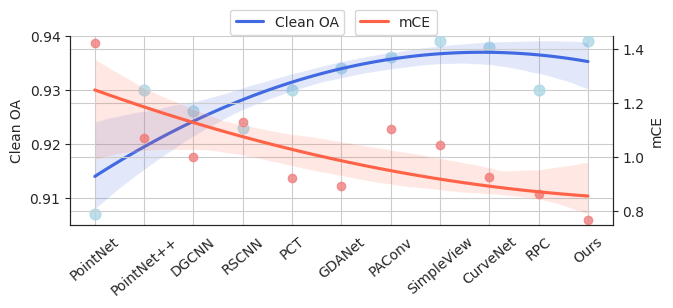

In [7]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = '0'  #代表只使用第3个gpu

import seaborn as sns
import matplotlib.pyplot as plt


clean_OA = [0.907, 0.930, 0.926,  0.923, 0.930, 0.934,
            0.936, 0.939, 0.938, 0.930, 0.939]
mCE      = [1.422, 1.072, 1.0, 1.130, 0.925, 0.892,
            1.104, 1.047, 0.927, 0.863, 0.766]

method   = ['PointNet', 'PointNet++', 'DGCNN', 'RSCNN', 'PCT', 'GDANet',
            'PAConv', 'SimpleView', 'CurveNet', 'RPC', 'Ours']

length = list(range(len(method)))

figsize = (7, 3)
fig, ax1 = plt.subplots(figsize=figsize)
ax2 = ax1.twinx()

ax1.set_ylim(0.905, 0.94)
ax2.set_ylim(0.75, 1.45)

sns.set_style('white')

mn_ax1 = sns.regplot(x=length, y=clean_OA, scatter=True,
                    ci=68, order=2, fit_reg=True, ax=ax1,
                    scatter_kws={'color': 'lightblue', 's': 60}, line_kws={'color': 'royalblue', 'label': 'Clean OA'},
                    )

mn_ax2 = sns.regplot(x=length, y=mCE, scatter=True,
                    ci=70, order=2, fit_reg=True, ax=ax2,
                    scatter_kws={'color': 'lightcoral'}, line_kws={'color': 'tomato', 'label': 'mCE'},
                    )

ax1.grid(True)  # 打开网格
ax2.grid(True)  # 打开网格

# 设置y轴标签
ax1.set_ylabel('Clean OA')
ax2.set_ylabel('mCE')

ax1.legend(loc='upper center', bbox_to_anchor=(0.40, 1.175), fancybox=True, shadow=False, ncol=2)
ax2.legend(loc='upper center', bbox_to_anchor=(0.60, 1.175), fancybox=True, shadow=False, ncol=2)

# 更换x轴
ax1.set_xticks(length)
ax1.set_xticklabels(method, rotation=40)
ax2.set_xticks(length)
ax2.set_xticklabels(method, rotation=40)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.margins(0.2)
plt.subplots_adjust(bottom=0.25)

plt.savefig('./vis_util/visualization/oa_mce/OA_mCE.pdf', dpi=300.0)
plt.savefig('./vis_util/visualization/oa_mce/oa_mce.jpg', dpi=300.0)

plt.show()
